# RAG
Sabendo que RAG é essencial para assistentes e agentes, que expande a 
capacidade do LLM utilizando um recurso menos custoso, e adicionando potencial aos 
modelos, criar uma aplicação usando um tipo de RAG para fornecer respostas rápidas 
(Standard), múltiplos agentes (Agentic) ou auto-reflexão (Self-Reflective). Usar os dados 
dos datasets docentesDC ou diariosPrefeituras para criar a solução de IA. Criar um 
benchmark com 30 perguntas para avaliar a qualidade da solução antes e depois do 
processo de RAG. Analisar o grau de contribuição do RAG. 

## Sobre a solução desenvolvida

Optou-se por utilizar o dataset dos Diários Oficiais das Prefeituras, e o modelo QWEN 3: 4B para implementação de um RAG com auto-reflexão (Self-Reflective).

In [1]:
#imports necessários
import pandas as pd
import re
import matplotlib.pyplot as plt
from datasets import load_dataset
from langchain_text_splitters import RecursiveCharacterTextSplitter
from IPython.display import display
from langchain_ollama import OllamaEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from qdrant_client.models import PointStruct, Distance, VectorParams
from langchain_ollama import ChatOllama
from typing import List, Dict, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from ragas import EvaluationDataset
from ragas.metrics import Faithfulness, AnswerRelevancy
from ragas.llms import LangchainLLMWrapper
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision
)
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset

c:\Users\raffa\Documents\UFPI\Tópicos em IA\Trabalho Final\implementacao_trabalho_final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# modificação para facilitar o debug
debug = True

### CARREGAMENTO DOS DADOS
Primeiramente, carregamos os dados presentes no dataset do HuggingFace, disponibilizado por um dos grupos, contendo os dados dos documentos de todas as prefeituras. Com o intuito de economizar processamento durante a bateria de testes do pipeline, de início, selecionamento uma pequena amostra dos dados, considerando apenas o território "Vale do Sambito", composto por 15 municípios, um deles sendo Valença do Piauí.

In [3]:
# carregamento de uma amostra do dataset (Vale do Sambito)

ds = load_dataset("gutoportelaa/DOMPI-2025", name="raw", split=["vale_do_sambito", "entre_rios"])

print(f"Número de registros: {len(ds)}\n")
print(ds[0:5])

# comentar a linha abaixo quando executar com o dataset completo
# ds = ds[0:5]

Número de registros: 2

[Dataset({
    features: ['id_publicacao', 'territorio', 'municipio', 'tipo_ato', 'data_publicacao', 'ano', 'extrator', 'texto', 'n_chars', 'paginas', 'extraido_em', 'extracao_segundos'],
    num_rows: 600
}), Dataset({
    features: ['id_publicacao', 'territorio', 'municipio', 'tipo_ato', 'data_publicacao', 'ano', 'extrator', 'texto', 'n_chars', 'paginas', 'extraido_em', 'extracao_segundos'],
    num_rows: 1066
})]


In [4]:
# unimos os splits carregados em `ds` (ex.: vale_do_sambito + entre_rios)
splits = ds if isinstance(ds, list) else [ds]

dfs_splits = []
for split in splits:
    if isinstance(split, pd.DataFrame):
        df_split = split.copy()
    else:
        to_pandas_fn = getattr(split, "to_pandas", None)
        if callable(to_pandas_fn):
            df_split = to_pandas_fn()
        elif isinstance(split, dict):
            df_split = pd.DataFrame([split])
        else:
            df_split = pd.DataFrame(split) # type: ignore

    dfs_splits.append(df_split)

# concatena os DataFrames dos splits, alinhando as colunas
todas_colunas = sorted(set().union(*(df_.columns for df_ in dfs_splits)))
dfs_splits = [df_.reindex(columns=todas_colunas) for df_ in dfs_splits]

# dataset final unificado (linhas de ambas as prefeituras/splits)
ds = pd.concat(dfs_splits, ignore_index=True)

print(f"Total de registros unificados: {len(ds)}")
print(f"Total de colunas: {len(ds.columns)}")

df = ds.copy()

Total de registros unificados: 1666
Total de colunas: 12


In [5]:
# retira o limite de tamanho máximo do texto em cada célula p/ melhor exibição
pd.set_option('display.max_colwidth', None)

### CHUNKING
Com base numa análise empírica da estrutura de alguns registros do split "Vale do Sambito", optamos por realizar o chunking seguindo a estratégia **"Document structure-based chunking"**. Esta estratégia se mostrou apropriada devido as estruturas semânticas existentes em grande parte dos arquivos, que costumam estar divididos por Artigos, Parágrafos, Blocos e Quebras de Linha. Dessa forma, com o auxílio do módulo do LangChain "RecursiveCharacterTextSplitter", realizamos o chunking dos diários, com chunking_size=1000 e chunk_overlap=150. Esse valores foram escolhidos considerando desempenho e o tamanho dos diários oficiais.

In [6]:
# configuração do Splitter Estrutural com Regex
custom_separators = [
    r"\nArt\.\s*\d+",               # Divide no início de Artigos (ex: Art. 1)
    r"\n§\s*\d+",                   # Divide em Parágrafos (ex: § 1º)
    r"\nPar[áa]grafo\s*[uúUÚ]nico", # Divide em Parágrafos Únicos
    r"\n\n",                        # Padrão de quebra de bloco
    r"\n",                          # Quebra de linha simples
    r" "                            # Espaço (último recurso se o texto for gigante)
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,           # limite máximo de caracteres por chunk
    chunk_overlap=150,         # margem de segurança para não cortar contextos no meio
    separators=custom_separators,
    is_separator_regex=True    
)

In [7]:
# etapa de processamento e enriquecimento dos chunks
chunks_finais: list = []

# iteramos linha por linha (cada linha é uma publicação de um município)
for idx, row in df.iterrows(): # type: ignore
    
    # ignoramos linhas cujo texto esteja vazio por algum erro de extração anterior
    if not row['texto'] or pd.isna(row['texto']):
        continue
        
    # eexecuta o chunking estrutural apenas na coluna de texto
    texto_chunks = splitter.split_text(row['texto'])
    
    # para cada pedaço gerado, criamos um objeto unindo o texto aos metadados da linha
    for i, chunk_text in enumerate(texto_chunks):
        dados_do_chunk = {
            # O ID do chunk mistura o ID original com o índice do pedaço criado
            "id_chunk": f"{row['id_publicacao']}_chunk_{i}",
            "id_publicacao_original": row['id_publicacao'],
            
            # Conteúdo que será transformado em vetor (Embedding)
            "texto_chunk": chunk_text.strip(),
            
            # Metadados essenciais para filtros e contexto no RAG
            "metadata": {
                "territorio": row['territorio'],
                "municipio": row['municipio'],
                "tipo_ato": row['tipo_ato'],
                "data_publicacao": row['data_publicacao'],
                "ano": int(row['ano']) if pd.notna(row['ano']) else None,
                "paginas_originais": row['paginas']
            }
        }
        chunks_finais.append(dados_do_chunk)

In [8]:
# 4. visualização do resultado
df_chunks = pd.DataFrame(chunks_finais)
print(f"Total de chunks gerados a partir de 1600 publicações: {len(df_chunks)}\n")
print(df_chunks[['id_chunk', 'texto_chunk', 'metadata']].head(3))

Total de chunks gerados a partir de 1600 publicações: 85794

                                   id_chunk  \
0  08ee6d9cf505689afc5858ceeb50c6ff_chunk_0   
1  08ee6d9cf505689afc5858ceeb50c6ff_chunk_1   
2  08ee6d9cf505689afc5858ceeb50c6ff_chunk_2   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [9]:
display(df_chunks[['id_chunk', 'texto_chunk', 'metadata']].tail(3))

,id_chunk,texto_chunk,metadata
85791,41aa44018ef508415d4123465aa16dca_chunk_3,"CMDI do Município de Agua Branca-PI, para o bienio 2025 a 2027.\nO PREFEITO Municipal DE AGUA BRANCA, ESTADO DO Piauí, no uSO de suas\natribuigoes legais que Ihe foram conferidas pelo Art. 82 da Lei Organica do Município\nACoo\nenadoria dos Conselhos Municipais da cidade de Agua Bra:\nPI, no uso de suas\natribuigoes legais, fulcrado na legislacao patria vigente relativa ao\ncontrole social das politicas\npublicas, e considerando o resultado da eleicao realizada em reuniao plenaria no dia 20 de outubro de\n2025,\nRESOLVE:\nRESOLVE:","{'territorio': 'entre_rios', 'municipio': 'Ãgua Branca', 'tipo_ato': 'Portaria', 'data_publicacao': '02/12/2025', 'ano': 2025, 'paginas_originais': 1}"
85792,41aa44018ef508415d4123465aa16dca_chunk_4,"Art.1Ficam\no Conselho Municipal dos Direitos da Pessoa\nArt. 1. - Fica concedida uma Gratificacao por Condigao Especial de Trabalho - GCET\nIdosa -- CMDI, para o bienio 2025-2027, conforme segue:\n- X, para o servidor RICARDO DE MATOS SOUSA , matricula N1012763, em face\n1. MARIA DO CEU DA SILVA BARRADAS FEITOSA - CPF: 297.703.603-25\ndas funcoes por ele exercidos, nos termos da Lei Municipal n.718/2025.\nPresidente do Conselho Municipal dos Direitos do Idoso -- CMDI\n2. MARIA LORENA RODRIGUES DE CARVALHO-CPF:074.514.483-76\nArt. 3. - Esta Portaria entra em vigor na data de sua publicacao, revogadas as.\nVice-Presidente do Conselho Municipal dos Direitos do Idoso -- CMDI\ndisposicoes em contrario.\n3. ANTONIA CLAUDIA SANTOS - CPF: 011.853.123-90\nExecutiva do Conselho Municipal dos Direitos do Idoso - CMDI\nDe- se ciencia,\nPublique- se e","{'territorio': 'entre_rios', 'municipio': 'Ãgua Branca', 'tipo_ato': 'Portaria', 'data_publicacao': '02/12/2025', 'ano': 2025, 'paginas_originais': 1}"
85793,41aa44018ef508415d4123465aa16dca_chunk_5,"Art. 2 Os me\nCumpra-se.\nResolução.\nGabinete do Prefeito Municipal de Agua Branca, Estado do Piauí, 28 de Novembro do\nano de 2025.\nAgua Branca - PI, 01 de deze\nnbro de 2025\ngovbr SHIEY\nCURY\nJoseRjbeit8 da Cruz Junior\nRreteito Municipal\nSHIRLEY FABIANA CURY SOARE\nCoordenadora Municipal dos Conselhos Municipais\nDiario Oficial dos Municipios\nA prova documental dos atos municipais","{'territorio': 'entre_rios', 'municipio': 'Ãgua Branca', 'tipo_ato': 'Portaria', 'data_publicacao': '02/12/2025', 'ano': 2025, 'paginas_originais': 1}"


### GERAÇÃO DAS EMBEDDINGS
O BAAI/bge-m3 é um modelo de embedding multilíngue de alta performance desenvolvido pela BAAI (Beijing Academy of Artificial Intelligence). Ele se destaca por sua versatilidade no processamento de linguagem natural e tarefas de Recuperação Aumentada de Geração (RAG). Escolhido para esta tarefa devido a capacidade de gerar **vetores densos (similaridade semântica), vetores esparsos (busca por palavra-chave exata, ideal para achar o número de uma lei ou CNPJ) e busca multi-vetor, tudo ao mesmo tempo**. Além disso, é um modelo relativamente leve e que consegue ser executado localmente sem nenhum custo adicional.

In [10]:
# Rodamos o modelo em segundo plano via Ollama, pré-instalado
# executar a célula somente caso o modelo não esteja rodando
!ollama run bge-m3

^C


In [11]:
# inicializamos o modelo local escolhido
embeddings_model = OllamaEmbeddings(model="bge-m3")

In [ ]:
def embed_em_lotes(modelo, textos, batch_size=16):
    vetores = []
    for i in range(0, len(textos), batch_size):
        lote = textos[i:i + batch_size]
        print(f"Processando lote {i//batch_size + 1} ({len(lote)} textos)...")
        vetores.extend(modelo.embed_documents(lote))
    return vetores

lista_de_textos = df_chunks["texto_chunk"].tolist()
vetores = embed_em_lotes(embeddings_model, lista_de_textos, batch_size=8)

Processando lote 1 (8 textos)...
Processando lote 2 (8 textos)...
Processando lote 3 (8 textos)...
Processando lote 4 (8 textos)...
Processando lote 5 (8 textos)...
Processando lote 6 (8 textos)...
Processando lote 7 (8 textos)...
Processando lote 8 (8 textos)...
Processando lote 9 (8 textos)...
Processando lote 10 (8 textos)...
Processando lote 11 (8 textos)...
Processando lote 12 (8 textos)...
Processando lote 13 (8 textos)...
Processando lote 14 (8 textos)...
Processando lote 15 (8 textos)...
Processando lote 16 (8 textos)...
Processando lote 17 (8 textos)...
Processando lote 18 (8 textos)...
Processando lote 19 (8 textos)...
Processando lote 20 (8 textos)...
Processando lote 21 (8 textos)...
Processando lote 22 (8 textos)...
Processando lote 23 (8 textos)...
Processando lote 24 (8 textos)...
Processando lote 25 (8 textos)...
Processando lote 26 (8 textos)...
Processando lote 27 (8 textos)...
Processando lote 28 (8 textos)...
Processando lote 29 (8 textos)...
Processando lote 30 (8 

In [ ]:
# adicionamos os vetores como uma nova coluna em nosso dataframe de chunks
df_chunks['embedding'] = vetores

print(f"Sucesso! Foram gerados {len(vetores)} vetores.")
print(f"Dimensão de cada vetor: {len(vetores[0])}") # deve ser 1024 para o bge-m3

Nota-se que aproximadamente 1.670 registros geraram um total de 85.794 chunks (vetores).

### CARREGAMENTO DAS EMBEDDINGS NO BANCO VETORIAL
O Qdrant é um banco de dados vetorial nativo, escrito em Rust, extremamente leve e incrivelmente rápido.

Por que utilizamos? 
* Ele foi desenhado especificamente para lidar com bilhões de vetores. Ele gerencia o uso de memória RAM de forma brilhante, permitindo que você configure os índices para rodar em disco em vez de carregar tudo na memória.
* Filtros: Suporta filtragem por metadados de forma tão robusta e rápida quanto o Supabase (solução que, para um grande número de dados, pode ser preciso utilizar um plano pago).

No Qdrant, um Point é o equivalente a uma "linha" do dataset. É um objeto que junta, no mesmo lugar, tudo o que o banco precisa para trabalhar. Todo Point é composto obrigatoriamente por três partes:

* ID: Um identificador único (pode ser um número inteiro sequencial ou um UUID).

* Vector: O vetor numérico (e nosso caso, os 1024 números gerados pelo bge-m3 para aquele pedaço de texto). É isso que o Qdrant usa para fazer a busca semântica ultra-rápida.

* Payload: Um dicionário JSON que guarda os dados textuais e os metadados associados àquele vetor. É aqui dentro que ficam o texto original do chunk, o nome do município, o ano, etc. O Qdrant consegue ler esse payload para aplicar os filtros rígidos (ex: buscar apenas onde municipio == 'Aroazes').

In [15]:
# levantamos uma instância do banco de dados qdrant (RUST) para armazenamento das embeddings.
# ele é um banco local, gratuito e otimizado para lidar buscas de bilhões de vetores
!docker run -p 6333:6333 qdrant/qdrant

^C


In [21]:
# configuramos conexões locais
url_qdrant = "http://localhost:6333"
nome_colecao = "documentos_dom"

client = QdrantClient(url=url_qdrant)

In [ ]:
# etapas de transferência das embeddings para o banco Qdrant

# 1. criamos a coleção no Qdrant se ela não existir
if not client.collection_exists(nome_colecao):
    client.create_collection(
        collection_name=nome_colecao,
        vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
    )

# 2. transformamos as linhas do 'df_chunks' em "Points" do Qdrant
points = []
for idx, row in df_chunks.iterrows():
    points.append(
        PointStruct(
            id=idx, # o Qdrant aceita IDs numéricos sequenciais ou UUIDs # type: ignore
            vector=row['embedding'],
            payload={
                "page_content": row['texto_chunk'],
                "metadata": {
                    "id_chunk": row['id_chunk'],
                    "id_publicacao_original": row['id_publicacao_original'],
                    **row['metadata']
                }
            }
        )
    )
    
def upsert_em_lotes(client, collection_name, points, batch_size=500):
    for i in range(0, len(points), batch_size):
        lote = points[i:i + batch_size]
        print(f"Enviando lote {i//batch_size + 1} com {len(lote)} pontos...")
        client.upsert(
            collection_name=collection_name,
            points=lote,
            wait=True,
            timeout=120,
        )

# 3. enviamos os dados em lotes p/ evitar estouro de tamanho da requisição
upsert_em_lotes(client, nome_colecao, points, batch_size=500)

""" # 3. Enviamos para o banco local
print(f"Enviando {len(points)} pontos para o Qdrant local...")
client.upsert(collection_name=nome_colecao, points=points) """
print("✓ Tudo salvo com sucesso no Qdrant!")

Enviando lote 1 com 500 pontos...
Enviando lote 2 com 500 pontos...
Enviando lote 3 com 500 pontos...
Enviando lote 4 com 500 pontos...
Enviando lote 5 com 500 pontos...
Enviando lote 6 com 500 pontos...
Enviando lote 7 com 500 pontos...
Enviando lote 8 com 500 pontos...
Enviando lote 9 com 500 pontos...
Enviando lote 10 com 500 pontos...
Enviando lote 11 com 500 pontos...
Enviando lote 12 com 500 pontos...
Enviando lote 13 com 500 pontos...
Enviando lote 14 com 500 pontos...
Enviando lote 15 com 500 pontos...
Enviando lote 16 com 500 pontos...
Enviando lote 17 com 500 pontos...
Enviando lote 18 com 500 pontos...
Enviando lote 19 com 500 pontos...
Enviando lote 20 com 500 pontos...
Enviando lote 21 com 500 pontos...
Enviando lote 22 com 500 pontos...
Enviando lote 23 com 500 pontos...
Enviando lote 24 com 500 pontos...
Enviando lote 25 com 500 pontos...
Enviando lote 26 com 500 pontos...
Enviando lote 27 com 500 pontos...
Enviando lote 28 com 500 pontos...
Enviando lote 29 com 500 pont

### CARREGAMENTO DO MODELO: QWEN 3.5: 4B
O uso do modelo Qwen 3.5 (na faixa de 3B a 4B de parâmetros) é a escolha ideal para o nosso sistema de Self-Reflective RAG por três fatores cruciais: latência, suporte nativo ao português e eficiência em tarefas agênticas.

Como a arquitetura de reflexão exige que o modelo rode múltiplos loops de checagem para cada pergunta (avaliando a relevância de cada chunk um por um antes de gerar a resposta final), um modelo gigante traria uma latência proibitiva para o usuário. Com 4B de parâmetros, o Qwen processa essas tomadas de decisão estruturadas quase instantaneamente no ambiente local, mantendo o pipeline rápido.

Além disso, a família Qwen é amplamente reconhecida pelo seu excelente desempenho em dados multilingues, capturando com precisão as nuances formais e siglas da legislação de Diários Oficiais brasileiros, entregando a inteligência de um modelo de grande porte com a velocidade e o custo zero de uma infraestrutura estritamente local.

In [17]:
# Vamos utilizar o modelo QWEN 3.5: 4B
!ollama run qwen3.5:4b

^C


In [130]:
# carregamos o modelo com a ajuda do módulo ChatOllama, passando uma temperatura baixa, para evitar alucinações
llm = ChatOllama(model="qwen3.5:4b", temperature=0.2, num_ctx=2048)
llm_j = ChatOllama(model="qwen3.5:4b", temperature=0.2, format="json")
llm_ragas = ChatOllama(model="qwen3.5:4b", temperature=0.0, format="json")

In [ ]:
def embed_em_lotes(modelo, textos, batch_size=16):
    vetores = []
    for i in range(0, len(textos), batch_size):
        lote = textos[i:i + batch_size]
        print(f"Processando lote {i//batch_size + 1} ({len(lote)} textos)...")
        vetores.extend(modelo.embed_documents(lote))
    return vetores

lista_de_textos = df_chunks["texto_chunk"].tolist()
vetores = embed_em_lotes(embeddings_model, lista_de_textos, batch_size=8)

Processando lote 1 (8 textos)...
Processando lote 2 (8 textos)...
Processando lote 3 (8 textos)...
Processando lote 4 (8 textos)...
Processando lote 5 (8 textos)...
Processando lote 6 (8 textos)...
Processando lote 7 (8 textos)...
Processando lote 8 (8 textos)...
Processando lote 9 (8 textos)...
Processando lote 10 (8 textos)...
Processando lote 11 (8 textos)...
Processando lote 12 (8 textos)...
Processando lote 13 (8 textos)...
Processando lote 14 (8 textos)...
Processando lote 15 (8 textos)...
Processando lote 16 (8 textos)...
Processando lote 17 (8 textos)...
Processando lote 18 (8 textos)...
Processando lote 19 (8 textos)...
Processando lote 20 (8 textos)...
Processando lote 21 (8 textos)...
Processando lote 22 (8 textos)...
Processando lote 23 (8 textos)...
Processando lote 24 (8 textos)...
Processando lote 25 (8 textos)...
Processando lote 26 (8 textos)...
Processando lote 27 (8 textos)...
Processando lote 28 (8 textos)...
Processando lote 29 (8 textos)...
Processando lote 30 (8 

In [36]:
# para usar o banco já carregado:

# from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore
from langchain_ollama import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")
client = QdrantClient(url="http://localhost:6333")

vector_store = QdrantVectorStore(
    client=client,
    collection_name="documentos_dom",
    embedding=embeddings_model
)

# optamos por passar os top-4 vetores mais aproximados para avaliação do QWEN
retriever = vector_store.as_retriever(search_kwargs={"k": 4})


### PIPELINE DO RAG
O pipeline do RAG começa logo após a preparação dos documentos(chunking). Depois, cada chunk é convertido em embedding e salvo no Qdrant junto com seus metadados. Quando o usuário faz uma pergunta, o sistema gera a embedding da consulta, busca os chunks mais próximos no banco vetorial e então avalia quais realmente são relevantes. Se houver documentos úteis, o LLM responde usando esse contexto recuperado; se não houver, o fluxo cai no fallback e gera uma resposta com conhecimento próprio geral.

In [55]:

import math

# DEFINIÇÃO DO ESTADO DO GRAFO
# o estado define quais informações são passadas de um nó para o outro
class GraphState(TypedDict):
    pergunta: str
    documentos: List[str]
    resposta: str
    status_retrieval: str  # Pode ser "com_dados" ou "sem_dados"


# DEFINIÇÃO DOS NÓS (FUNÇÕES)

def _extrair_tokens_relevantes(texto: str) -> List[str]:
    """Extrai tokens úteis da pergunta para um filtro lexical leve."""
    stopwords = {
        "qual", "quais", "como", "onde", "quando", "porque", "porque",
        "para", "com", "sem", "sobre", "entre", "de", "da", "do",
        "das", "dos", "em", "no", "na", "nos", "nas", "um", "uma",
        "o", "a", "os", "as", "é", "ser", "foi", "são", "esta",
        "esse", "essa", "isso", "isto", "ao", "aos", "à", "às"
    }
    tokens = re.findall(r"[a-zA-ZÀ-ÿ0-9]+", texto.lower())
    return [token for token in tokens if len(token) >= 3 and token not in stopwords]


def recuperar_documentos(state: GraphState) -> Dict[str, Any]:
    
    pergunta = state["pergunta"]
    if debug:
        print("--- RECUPERANDO DOCUMENTOS DO QDRANT ---")
        print(f"Pergunta recebida: {pergunta}")

    # etapas:
    # 1. recupera os objetos completos do Qdrant (não apenas o texto)
    docs_recuperados = retriever.invoke(pergunta)
    if debug:
        print(f"Qdrant retornou {len(docs_recuperados)} candidatos.")

    textos_enriquecidos = []
    for indice, doc in enumerate(docs_recuperados, start=1):
        # 2. captura os metadados que jogamos no nível principal do payload do Qdrant
        municipio = doc.metadata.get("municipio", "Não especificado")
        tipo_ato = doc.metadata.get("tipo_ato", "Não especificado")
        trecho = " ".join(doc.page_content.split())[:300]
        if debug:
            print(f"  - Candidato {indice}: município={municipio} | tipo_ato={tipo_ato} | trecho={trecho}")

        # 3. cria uma string que une o Contexto Macro (Metadados) ao Contexto Micro (Chunk)
        texto_com_contexto = (
            f"[CONTEXTO DA PUBLICAÇÃO - Município: {municipio} | Tipo de Ato: {tipo_ato}]\n"
            f"{doc.page_content}"
        )
        textos_enriquecidos.append(texto_com_contexto)

    return {"documentos": textos_enriquecidos}


def avaliar_documentos(state: GraphState) -> Dict[str, Any]:
    """Avalia se os documentos recuperados são realmente relevantes."""
    if debug:
        print("--- AVALIANDO RELEVÂNCIA COM QWEN ---")
    pergunta = state["pergunta"]
    documentos = state["documentos"]

    tokens_pergunta = _extrair_tokens_relevantes(pergunta)
    total_tokens = len(tokens_pergunta)
    
    limiar_lexical = math.ceil(total_tokens / 3) if total_tokens > 0 else 1
    
    if debug:
        print(f"Tokens úteis da pergunta ({total_tokens}): {tokens_pergunta}")
        print(f"Limiar de sobreposição lexical (1/3): {limiar_lexical}")

    documentos_validos = []

    # Mudamos o prompt para forçar um esquema JSON estrito que o llm_j aceita
    prompt_avaliador = """{{
        "instrucao": "Você é um auditor rigoroso de Diários Oficiais. Avalie se o documento fornecido contém informações úteis para responder à pergunta.",
        "pergunta": "{pergunta}",
        "documento": "{documento}",
        "formato_saida": "Responda obrigatoriamente no formato JSON abaixo, preenchendo a chave 'relevante' com true ou false",
        "exemplo": {{ "relevante": true }}
    }}"""

    for doc in documentos:
        doc_normalizado = doc.lower()
        tokens_encontrados = [token for token in tokens_pergunta if token in doc_normalizado]
        num_encontrados = len(tokens_encontrados)

        if num_encontrados >= limiar_lexical:
            if debug:
                print(f"✅ Documento aceito por sobreposição lexical ({num_encontrados}/{total_tokens} tokens): {tokens_encontrados}")
            documentos_validos.append(doc)
            continue

        if debug:
            print(f"⚠️ Sobreposição lexical insuficiente ({num_encontrados}/{total_tokens}). Enviando para avaliação estruturada do LLM...")
            
        resposta = llm_j.invoke(prompt_avaliador.format(pergunta=pergunta, documento=doc))
        
        # Como o retorno agora é obrigatoriamente um JSON, tratamos a string de forma segura
        import json
        try:
            dados_julgamento = json.loads(resposta.content)
            is_relevante = dados_julgamento.get("relevante", False)
        except Exception:
            is_relevante = "SIM" in resposta.content.upper() # Fallback de string pura
            
        if debug:
            print(f"Julgamento estruturado do avaliador: {is_relevante}")

        if is_relevante:
            documentos_validos.append(doc)

    status = "com_dados" if documentos_validos else "sem_dados"
    if debug:
        print(f"Documentos validados: {len(documentos_validos)}")
    return {"documentos": documentos_validos, "status_retrieval": status}


def gerar_resposta_com_rag(state: GraphState) -> Dict[str, Any]:
    """Gera a resposta baseada estritamente nos documentos validados do Qdrant."""
    if debug:
        print("--- GERANDO RESPOSTA BASEADA NO DIÁRIO OFICIAL ---")
    pergunta = state["pergunta"]
    contexto = "\n\n".join(state["documentos"])

    prompt_rag = """Você é um assistente especialista em Diários Oficiais Municipais.
Responda à pergunta do usuário utilizando as informações do Contexto fornecido abaixo.
Seja principalmente OBJETIVO E DIRETO, evite responder de forma prolixa. Seja claro, formal e cite os artigos ou leis se eles aparecerem no texto.

Contexto:
{contexto}

Pergunta: {pergunta}

Resposta Baseada nos Documentos:
"""

    resposta = llm.invoke(prompt_rag.format(contexto=contexto, pergunta=pergunta))
    return {"resposta": response.content if (response := resposta) else ""}


def gerar_resposta_fallback(state: GraphState) -> Dict[str, Any]:
    """Gera a resposta padrão, caso o RAG não tenha encontrado nada."""
    if debug:
        print("--- FALLBACK: GERANDO RESPOSTA CONHECIMENTO GERAL DO MODELO ---")
    pergunta = state["pergunta"]

    prompt_fallback = """Você é um assistente de inteligência artificial.
O usuário fez uma pergunta sobre legislação ou administração municipal, mas não encontramos esses dados específicos nos arquivos locais.

Pergunta: {pergunta}

Resposta Geral:
"""
    resposta = llm.invoke(prompt_fallback.format(pergunta=pergunta))
    return {"resposta": response.content if (response := resposta) else ""}




# 4. ARESTA CONDICIONAL (TOMADA DE DECISÃO)
def decidir_geracao(state: GraphState) -> str:
    """Roteia o fluxo dependendo do resultado da avaliação do Qwen."""
    if state["status_retrieval"] == "com_dados":
        return "gerar_com_rag"
    else:
        return "gerar_fallback"




# 5. MONTAGEM DO GRAFO (LANGGRAPH)
workflow = StateGraph(GraphState)

# adicionamos os nós no fluxo
workflow.add_node("recuperar", recuperar_documentos)
workflow.add_node("avaliar", avaliar_documentos)
workflow.add_node("gerar_com_rag", gerar_resposta_com_rag)
workflow.add_node("gerar_fallback", gerar_resposta_fallback)

# desenhamos as conexões
workflow.add_edge(START, "recuperar")
workflow.add_edge("recuperar", "avaliar")

# definimos a decisão condicional saindo do nó 'avaliar'
workflow.add_conditional_edges(
    "avaliar",
    decidir_geracao,
    {
        "gerar_com_rag": "gerar_com_rag",
        "gerar_fallback": "gerar_fallback"
    }
)

# fim do fluxo para ambos os caminhos de geração
workflow.add_edge("gerar_com_rag", END)
workflow.add_edge("gerar_fallback", END)

# compilamos o grafo final p/ execução
app = workflow.compile()

In [40]:
# teste 01 com uma entrada que possui informações relacionadas no banco

debug_og = debug
debug = True

entrada_1 = {"pergunta": "Qual é o objetivo do Centro Integrado Multidisciplinar criado em Aroazes?"}
resultado_1 = app.invoke(entrada_1) # type: ignore

debug = debug_og

print("\n=== RESPOSTA FINAL ===")
print(resultado_1["resposta"])

--- RECUPERANDO DOCUMENTOS DO QDRANT ---
Pergunta recebida: Qual é o objetivo do Centro Integrado Multidisciplinar criado em Aroazes?
Qdrant retornou 4 candidatos.
  - Candidato 1: município=Aroaze S | tipo_ato=lei | trecho=Art. 11 - Esta Lei entrara em vigor na data de sua publicacao. Art. 9 - O fluxo de recebimento e os protocolos de atendimento serao definidos em Regimento proprio do Centro Integrado Multidisciplinar. Id:09FeD8A9487D66B2 ESTADO E AROAZE 84/0001-39 AROAZEs Lei n364/2025 PI,10 d de 2025 Dispoe sobre a
  - Candidato 2: município=Agua  Branca | tipo_ato=Decreto | trecho=## ld: 13B5BF20141D67 AF <!-- image --> REF. PROC. Nº 005/2025 DISPENSA N' 00512025 OBJETO: contratação de empresa através de Licitação , tendo como objeto contratação de empresa para prestação especializados SISTEMA INTEGRADO DE ADMINISTRAÇÃO CONTROLE (SIAFC), para atender as necessidades da Câmara
  - Candidato 3: município=Aroazes | tipo_ato=Edital | trecho=| | Prefeitura Municipal de Aroazes | | |
  

In [41]:
# teste 02 com uma entrada que não possui informações relacionadas no banco
debug_og = debug
debug = True

entrada_2 = {"pergunta": "Qual a raiz quadrada de 95?"}
resultado_2 = app.invoke(entrada_2) # type: ignore

debug = debug_og

print("\n=== RESPOSTA FINAL ===")
print(resultado_2["resposta"])

--- RECUPERANDO DOCUMENTOS DO QDRANT ---
Pergunta recebida: Qual a raiz quadrada de 95?
Qdrant retornou 4 candidatos.
  - Candidato 1: município=Aroazes  Valor | tipo_ato=lei | trecho=| 95.000,00 | | |
  - Candidato 2: município=Lagoa  Do  Pi | tipo_ato=Contrato | trecho=| | | | | 95.000,00 | | |
  - Candidato 3: município=Uniao | tipo_ato=LRF | trecho=| . 815 . 0,00 | 95 o, 00 | 2 . o, 00 |
  - Candidato 4: município=Lagoa  Do  Pi | tipo_ato=decreto | trecho=| 95.000,00 | 95.000,00 | 95.000,00 | 95.000,00 | 95.000,00 | 95.000,00 | 95.000,00 |
--- AVALIANDO RELEVÂNCIA COM QWEN ---
Tokens úteis da pergunta (2): ['raiz', 'quadrada']
Limiar de sobreposição lexical (1/3): 1
⚠️ Sobreposição lexical insuficiente (0/2). Enviando para avaliação do LLM...
Julgamento do avaliador: NAO
⚠️ Sobreposição lexical insuficiente (0/2). Enviando para avaliação do LLM...
Julgamento do avaliador: NAO
⚠️ Sobreposição lexical insuficiente (0/2). Enviando para avaliação do LLM...
Julgamento do avaliador: NAO


### AVALIAÇÃO DOS RESULTADOS


In [46]:
# definição do benchmark com base nos Diários Oficiais
benchmark_base = [
    {
        "question": "Qual centro oferece suporte aos alunos do Município de Aroazes?",
        "ground_truth": "O Centro Integrado Multidisciplinar - CIM.",
        "contexts": ["Art. 1 - Fica a Prefeitura Municipal de Aroazes autorizada a implantar o Centro Integrado Multidisciplinar - CIM, para atendimento especializado as criangas, adolescentes e adultos da Rede Municipal de Ensino."]
    },
    {
        "question": "Em qual localidade e horário ocorreu a solenidade conjunta de posse dos Vereadores, Prefeito e Vice-prefeita de Aroazes em 01/01/2025?",
        "ground_truth": "No Ginásio de Esportes da unidade Escolar Manoel Portela de Carvalho, às 19:00h.",
        "contexts": ["Ao primeiro dia do mes de janeiro do ano de dois mil e vinte e cinco (01/01/2025), as 19:00h, no Ginasio de Esportes da unidade Escalar Manoel Portela de Carvalho, onde foi instalada a sede do Poder Legislativo para esse ato, deu-se a solenidade conjunta de posse dos Vereadores, Prefeito e Vice- prefeita eleitos"]
    },
    {
        "question": "Qual é o número de telefone da Prefeitura de Aroazes listado em suas publicações?",
        "ground_truth": "(89) 3468-1345",
        "contexts": ["Prefeitura Municipal DE AROAZES C.N.P.J.: 06.554.984/0001-39 Av. 27 de Fevereiro, 691, Centro CEP: 64310-000 Id:15190424F5C3F0B8 F E-mail: aroazes.pi@hotmail.com ARoAzes Tel: (89) 3468-1345"]
    },
    {
        "question": "Qual é o endereço completo da Prefeitura Municipal de Elesbão Veloso informado nos documentos de 2025?",
        "ground_truth": "Praça José Martins, 41, Bairro Vermelha - Elesbão Veloso - CEP: 64.325-000",
        "contexts": ["Prefeitura Municipal de Elesbão Veloso. Praça José Martins, 41, Bairro Vermelha. -. Elesbão Veloso CNPJ: 06.$54.844/0001-60 - CEP: 64.325-000."]
    },
    {
        "question": "Qual o nome da presidente da Câmara Municipal de Agricolândia que assinou a Portaria nº 04/2025 do município?",
        "ground_truth": "Edith Ribeiro Alencar",
        "contexts": ["EDITH RIBEIRO ALENCAR"]
    },
    {
        "question": "Qual o CNPJ da Prefeitura de Barro Duro, Piauí?",
        "ground_truth": "06.554.745/0001-89",
        "contexts": ["PREFEITURA MUNICIPAL DE BARRO DURO Av. Cel. Benedito da Luz, 675 - Centro - CNPJ. 06.554.745/0001-89"]
    },
    {
        "question": "Qual o número de telefone da Prefeitura de Barro Duro, Piauí?",
        "ground_truth": "(86) 3284-1216",
        "contexts": ["Fone: (86) 3284-1216- Fax (86) 3284-1303 BARRO DURO -PIAUI"]
    },
    {
        "question": "Quais são as duas principais obrigações e papéis definidos nos Artigos 2º e 3º para os servidores indicados na Portaria da prefeitura de Elesbão Veloso sobre acompanhamento contratual?",
        "ground_truth": "Ao Gestor compete gerenciar o contrato até o término de sua vigência e responder pelo exercício das atribuições; ao Fiscal compete fiscalizar a execução e relatar incidentes contratuais ao gestor.",
        "contexts": ["Art. 2-Compete ao servidor, designado como gestor dos contratos de que trata essa Portaria, gerenciaro dido contrato até o término de sua vigência. ( gestor acima designado responde pelo exercicio das atribuições a ele confiadas. Art. 3° Compete aos servidores, designados como fiscal dos contratos em comento, fiscalizar a execução, relatando ao gestor do contrato os incidentes contratuais para que tome as providenciascabíveis"]
    },
    {
        "question": "Qual o objeto do Pregão adiado pela prefeitura de Brasileira-PI em 23/12/2025?",
        "ground_truth": "Tem como objeto o registro de preços para futura aquisição de gêneros alimentícios para merenda escolar a ser ofertada aos alunos das escolas da Rede Municipal de Ensino do município, para o exercício financeiro de 2026",
        "contexts": ["O Município de BRASILEIRA (PI) informa que está adiando o Pregão Eletrônico que tem como Objeto: Registro de preços para futura aquisição de gêneros alimentícios para merenda escolar a ser ofertada aos alunos das escolas da Rede Municipal de Ensino de Brasileira-PI, para o exercício financeiro 2026."]
    },
    {
        "question": "Qual o período do recesso de fim de ano decretado pelo município de Ilha Grande (PI) em 2025?",
        "ground_truth": "O recesso ocorre do dia 23 de dezembro de 2025 até o dia 02 de janeiro de 2026.",
        "contexts": ["Art.1- Fica decretado RECESsO durante o periodo de NATAL e REVEILLON, do dia 23 de dezembro de 2025 ate o dia 02 de janeiro de 2026 em todos os orgaos e entidades da Administragao Publica Municipal"]
    },
    {
        "question": "Quem foi dispensado do Licenciamento Ambiental pela prefeitura de Marcolândia do Piauí em 05/11/2025?",
        "ground_truth": "João Balista Pires",
        "contexts": ["Marcolãndia do Piauí­ DECLARA que o Sr\" João Balista Pires, Inscrito no CPF: 005.353.894-34 localizado no Municíp io de Araripina Pernambuco, SN, CEP:56.280-000 Zona Rural· fica DISPENSADO do licenciamento ambiental para realizar as atividades"]
    },
    {
        "question": "Quais são as partes envolvidas no Termo de Recisão Bilateral do contrato de N° 182/2025, do município de Miguel Leão?",
        "ground_truth": "O Município de Miguel Leão-PI e a Sra. Carla Rodrigues dos Santos Braga",
        "contexts": ["TERMO DE RESCISÃO BILATERAL DO CONTRATO Nº 182/2025, FIRMADO NA SEDE DA PREFEITURA MUNICIPAL DE MIGUEL LEÃO-PI, .QUE ENTRE SI FAZEM, DE UM LADO O · MUNICIPÍO DE MIGUEL LEÃO-PI, E DE' OUTRO LADO A SRA. CARLA RODRIGUES DOS SANTOS BRAGA"]
    },
    {
        "question": "Qual é o número identificador do Edital lançado pelo Instituto Legatus para a Prefeitura Municipal de Aroazes em 2025?",
        "ground_truth": "Edital nº 05/2025",
        "contexts": ["PREFEITURA MUNICIPAL DE AROAZES. AV. 27 DE FEVEREIRO, 691, CENTRO. CEP: 64310-000 – AROAZES – PI. CNPJ: 06.554.984/0001-39. E-MAIL: aroazes.pi@hotmail.com. TEL: (89) 3468-1345. EDITAL Nº 05/2025."]
    },
    {
        "question": "A Portaria N° 044/2025-CPC/PMEV, emitida em 02 de julho de 2025 pela Prefeitura de Elesbão Veloso, dispõe sobre a nomeação de gestor e fiscal para a aplicação de recursos de qual lei nacional?",
        "ground_truth": "Lei nº 14.399, de 8 de julho de 2022 (Política Nacional Aldir Blanc - PNAB)",
        "contexts": ["PORTARIA N° 044/2025-CPC/PMEV, DE 02 DE JULHO DE 2025. [...] NOMEAÇÃO DE GESTOR E FISCAL DE CONTRATO PARA PRESTAÇÃO DE SERVIÇOS DE EMPRESA ESPECIALIZADA EM ASSESSORIA E CONSULTORIA TÉCNICA/JURÍDICA, PARA GESTÃO E APLICAÇÃO DOS RECURSOS ORIUNDOS DA LEI Nº 14.399, DE 8 DE JULHO DE 2022 - POLÍTICA NACIONAL ALDIR BLANC PNAB"]
    },
    {
        "question": "Qual é a data de publicação da Portaria nº 04/2025 do município de Agricolândia?",
        "ground_truth": "07 de fevereiro de 2025",
        "contexts": ["Portaria no 04/2025\nAgricolandia/PI, 07 de fevereiro de 2025."]
    },
    {
        "question": "Qual é o ID numérico específico associado à Emenda Parlamentar de R$ 60.000,00 destinada à APAPI (Amigos Protetores dos Animais de Picos) mencionada no Diário Oficial do Piauí em julho de 2025?",
        "ground_truth": "ID Nº (017844255)",
        "contexts": ["CONSIDERANDO o Ofício Gabinete Nº 020/2025 ID Nº (017844255) que designa. Emenda Parlamentar, no valortotal de R$ 60.000,00 (sessenta mil reais), especificamente para a APAPI - AMIGOS PROTETORES DOS ANIMAIS DE PICOS (CNPJ Nº 22.235.523/0001-50);"]
    },
    {
        "question": "Quem recebeu o Título de Cidadão agricolandense segundo o Decreto Legislativo n.º 005/2025?",
        "ground_truth": "Sr. José Nilson Vieira de Almeida",
        "contexts": ["Concede Titulo de Cidadao agricolandense ao Sr. JOSE NILSON VIEIRA DE ALMEIDA."]
    },
    {
        "question": "Quem foi designada como Gestora e quem foi designado como Fiscal da Secretaria Municipal de Saúde e Saneamento de Elesbão Veloso para supervisionar o Contrato Administrativo N.° 060/2025?",
        "ground_truth": "Gestora: Rossana Cristie Feitosa Cavalcante; Fiscal: Deuhilton Soares Solon.",
        "contexts": ["CONTRATO ADMINISTRATIVO N.° 060/2025, firmado com a empresa M F FERREIRA - ME", "GESTOR SECRETARIA MUNICIPAL DE SAÚDE E SANEAMENTO: ROSSANA CRISTIE FEITOSA. CAVATCANTE, inscrita no CPF nº 604.592.693-56. FISCAL SECRETARIA MUNICIPAL DE SAÚDE E SANEAMENTO: DEUHILTON SOARES. SOLON, inscrita no CPF n\" 802.346.743-34."]
    },
    {
        "question": "Considerando o Contrato Administrativo N.° 060/2025 em Elesbão Veloso, qual é a empresa contratada e o seu CNPJ?",
        "ground_truth": "Empresa M F Ferreira - ME, CNPJ 60.730.304/0001-36.",
        "contexts": ["CONTRATO ADMINISTRATIVO N.° 060/2025, firmado com a empresa M F FERREIRA - ME, inscrita no CNPJ sob o n.° 60.730.304/0001-36"]
    },
    {
        "question": "No Diário Oficial do Piauí referente às ações do governo e municípios, qual artigo da Lei Federal Nº 13.019/2014 (MROSC) é textualmente citado para justificar as regras de aplicação de emendas parlamentares?",
        "ground_truth": "Art. 29",
        "contexts": ["CONSIDERANDO a Lei Federal Nº 13.019/2014, marco regulatório das organizações da sociedade civil – MROSC, precisamente no seu Art. 29, onde versa sobre os casos de emendas parlamentares"]
    }
]

Pipeline de avaliação do RAG com a Biblioteca RAGAS

In [124]:
# 1. ENCAPSULAMENTO DOS COMPONENTES EXISTENTES
print("Preparando juízes do RAGAS com componentes ativos...")

llm_juiz = LangchainLLMWrapper(llm_j) # type: ignore
embeddings_juiz = LangchainEmbeddingsWrapper(embeddings_model)

# a função do PROMPT_SEM_RAG é a mesma do nó de fallback, pois ambos avaliam a resposta sem considerar os documentos do RAG
PROMPT_SEM_RAG = """Você é um assistente de inteligência artificial.
O usuário fez uma pergunta. Responda o que puder com o seu conhecimento geral prévio.

Pergunta: {pergunta}

Resposta Geral:
"""

Preparando juízes do RAGAS com componentes ativos...


In [51]:
# 2. EXECUÇÃO DOS EXPERIMENTOS (COLETA VIA LANGGRAPH)
dados_sem_rag = []
dados_com_rag = []

In [53]:
# testando resposta sem RAG com uma pergunta do benchmark
for item in benchmark_base:
    pergunta = item["question"]
    ground_truth = item["ground_truth"]
    contexts = item["contexts"]

    # 2.1. Resposta sem RAG
    prompt_sem_rag = PROMPT_SEM_RAG.format(pergunta=pergunta)
    resposta_sem_rag = llm.invoke(prompt_sem_rag) # type: ignore

    dados_sem_rag.append({
        "user_input": pergunta,
        "references": ground_truth,
        "retrieved_contexts": contexts,
        "response": resposta_sem_rag.content if (resposta_sem_rag := resposta_sem_rag) else ""
    })

    # 2.2. Resposta com RAG
    entrada_grafo = {"pergunta": pergunta}
    resultado_grafo = app.invoke(entrada_grafo) # type: ignore

    dados_com_rag.append({
        "user_input": pergunta,
        "references": ground_truth,
        "retrieved_contexts": contexts,
        "response": resultado_grafo["resposta"]
    })
    
    break

print("Respostas coletadas")
print(dados_sem_rag[0])
print(dados_com_rag[0])

--- RECUPERANDO DOCUMENTOS DO QDRANT ---
Pergunta recebida: Qual centro oferece suporte aos alunos do Município de Aroazes?
Qdrant retornou 4 candidatos.
  - Candidato 1: município=Aroazes | tipo_ato=Edital | trecho=| | Prefeitura Municipal de Aroazes | | |
  - Candidato 2: município=Aroaze S | tipo_ato=lei | trecho=Art. 11 - Esta Lei entrara em vigor na data de sua publicacao. Art. 9 - O fluxo de recebimento e os protocolos de atendimento serao definidos em Regimento proprio do Centro Integrado Multidisciplinar. Id:09FeD8A9487D66B2 ESTADO E AROAZE 84/0001-39 AROAZEs Lei n364/2025 PI,10 d de 2025 Dispoe sobre a
  - Candidato 3: município=Lagoinha Do Piaui | tipo_ato=Decreto | trecho=Contrato n 078/2025. PREGAO ELETRONICO 001/2025. Objeto: Contratagao de empresa para fornecimento de servigos de locacao de veiculos, para atender as necessidades da Secretaria Municipal de Educagao de Aroazes. PARTES: O Município DE AROAZES, inscrito no CNPJ no 06.554.984/0001-39, situado na Av. 27
  - Can

In [54]:
if debug:
    print("\nIniciando execução do Benchmark através do pipeline...")

for item in benchmark_base:
    #ignorar o primeiro item, que já foi testado acima
    if item == benchmark_base[0]:
        continue
    
    q = item["question"]
    gt = item["ground_truth"]
    
    # --- EXPERIMENTO 1: SEM RAG (Conhecimento Prévio do Modelo) ---
    if debug:
        print(PROMPT_SEM_RAG.format(pergunta=q))
        print(f">>> Executando Sem RAG: '{q}'")
    # forçamos uma chamada direta ao modelo apenas para este teste isolado sem fontes
    resp_sem = llm.invoke(PROMPT_SEM_RAG.format(pergunta=q))
    if debug:
        print(f"Resposta Sem RAG: {resp_sem.content}")
    
    dados_sem_rag.append({
        "user_input": q,
        "response": resp_sem.content,
        "retrieved_contexts": [],
        "references": gt
    })


Iniciando execução do Benchmark através do pipeline...
Você é um assistente de inteligência artificial.
O usuário fez uma pergunta. Responda o que puder com o seu conhecimento geral prévio.

Pergunta: Em qual localidade e horário ocorreu a solenidade conjunta de posse dos Vereadores, Prefeito e Vice-prefeita de Aroazes em 01/01/2025?

Resposta Geral:

>>> Executando Sem RAG: 'Em qual localidade e horário ocorreu a solenidade conjunta de posse dos Vereadores, Prefeito e Vice-prefeita de Aroazes em 01/01/2025?'
Resposta Sem RAG: Com base no meu conhecimento geral prévio e na minha capacidade de acesso à informação atualizada em tempo real, **não tenho registros específicos sobre a localidade exata ou o horário da solenidade conjunta de posse ocorrida em 01/01/2025 para Aroazes.**

Isso ocorre porque:
1.  **Natureza dos Dados:** Detalhes administrativos locais e horários específicos de cerimônias municipais recentes (ou futuras, dependendo do contexto atual) geralmente não estão consolid

In [73]:
for item in dados_sem_rag:
    print(f"Pergunta: {item['user_input']}")
    print(f"Resposta: {item['response']}")
    print(f"Referência: {item['references']}\n")

Pergunta: Qual centro oferece suporte aos alunos do Município de Aroazes?
Resposta: Com base em meu conhecimento geral sobre o sistema educacional brasileiro e a estrutura administrativa comum dos municípios brasileiros:

Não há um centro específico ou entidade com nome próprio amplamente conhecido que seja exclusivamente dedicado ao suporte aos alunos do **Município de Aroazes** (localizado no estado da Bahia) além das estruturas padrão de gestão pública. Geralmente, o suporte educacional é oferecido através da rede escolar municipal e estadual sob a coordenação da **Secretaria Municipal de Educação**.

Em muitos municípios como este, as atividades de apoio aos alunos são realizadas dentro das escolas públicas municipais ou por meio de programas estaduais (como os do SEED/BA), mas não existe uma instituição distinta com o nome genérico "Centro de Suporte" que seja um fato geral conhecido. O suporte é geralmente integrado à gestão escolar local e às políticas educacionais vigentes no m

In [74]:
if debug:
    print("\nIniciando execução do Benchmark através do pipeline...")

for item in benchmark_base:
    q = item["question"]
    gt = item["ground_truth"]
    
    # --- EXPERIMENTO 2: COM RAG (Grafo Agêntico 'app') ---
    if debug:
        print(f">>> Executando Com RAG via Grafo: '{q}'")
    
    # acionamos o pipeline completo do LangGraph. Ele fará o retrieve, a avaliação 
    # pelo Qwen e decidirá se usa RAG ou se cai para o fallback de forma autônoma
    #  construímos um estado inicial que respeita o TypedDict GraphState esperado pelo grafo.
    initial_state : GraphState = {
        "pergunta": q,
        "documentos": [],
        "resposta": "",
        "status_retrieval": "sem_dados"
    }
    resultado_grafo = app.invoke(initial_state)
    
    # como o grafo já realiza a busca no Qdrant internamente, nós recuperamos os chunks 
    # finais que foram armazenados no estado do grafo para entregar à avaliação do RAGAS
    chunks_utilizados = resultado_grafo.get("documentos", [])
    resposta_final_grafo = resultado_grafo.get("resposta", "")
    
    dados_com_rag.append({
        "user_input": q,
        "response": resposta_final_grafo,
        "retrieved_contexts": chunks_utilizados,
        "references": gt
    })


Iniciando execução do Benchmark através do pipeline...
>>> Executando Com RAG via Grafo: 'Qual centro oferece suporte aos alunos do Município de Aroazes?'
--- RECUPERANDO DOCUMENTOS DO QDRANT ---
Pergunta recebida: Qual centro oferece suporte aos alunos do Município de Aroazes?
Qdrant retornou 4 candidatos.
  - Candidato 1: município=Aroazes | tipo_ato=Edital | trecho=| | Prefeitura Municipal de Aroazes | | |
  - Candidato 2: município=Aroaze S | tipo_ato=lei | trecho=Art. 11 - Esta Lei entrara em vigor na data de sua publicacao. Art. 9 - O fluxo de recebimento e os protocolos de atendimento serao definidos em Regimento proprio do Centro Integrado Multidisciplinar. Id:09FeD8A9487D66B2 ESTADO E AROAZE 84/0001-39 AROAZEs Lei n364/2025 PI,10 d de 2025 Dispoe sobre a
  - Candidato 3: município=Lagoinha Do Piaui | tipo_ato=Decreto | trecho=Contrato n 078/2025. PREGAO ELETRONICO 001/2025. Objeto: Contratagao de empresa para fornecimento de servigos de locacao de veiculos, para atender as ne

In [117]:
# 3. AVALIAÇÃO MATEMÁTICA COM O RAGAS
print("\nFormatando datasets para o RAGAS...")
dataset_sem_rag = EvaluationDataset.from_list(dados_sem_rag)
dataset_com_rag = EvaluationDataset.from_list(dados_com_rag)


Formatando datasets para o RAGAS...


In [118]:
display(dataset_sem_rag)
display(dataset_com_rag)

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response'], len=20)

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response'], len=20)

In [119]:
# célula para visualização prévia dos datasets formatados antes de rodar as métricas

display(dataset_sem_rag.to_pandas())
display(dataset_com_rag.to_pandas())

,user_input,retrieved_contexts,response
0,Qual centro oferece suporte aos alunos do Município de Aroazes?,[],"Com base no meu conhecimento geral sobre o sistema educacional brasileiro e informações disponíveis até minha última atualização:\n\nNão há um centro específico de grande repercussão nacional ou internacional que seja amplamente documentado como tendo suporte exclusivo para os alunos do **Município de Aroazes** (localizado na Bahia, Brasil) em termos de uma instituição única com esse nome. Geralmente, o suporte educacional e a gestão escolar são realizados através da rede pública municipal.\n\nO apoio aos estudantes nesse município costuma ser oferecido pela:\n1. **Secretaria Municipal de Educação:** É responsável por coordenar as políticas públicas, infraestrutura das escolas municipais e programas locais de ensino.\n2. **Escolas Públicas Municipais:** A maioria dos alunos é atendida em redes escolares estaduais ou municipais (como a Rede Estadual de Ensino do Estado da Bahia que atua na região).\n\nSe você busca informações específicas sobre um programa local recente ou uma instituição particular, recomenda-se verificar diretamente com:\n* O site oficial da **Secretaria Municipal de Educação** de Aroazes.\n* As escolas públicas mais próximas (como a Escola Estadual ou Centro Educacional locais).\n* Ou através do portal educacional estadual (**SEED/BA**) para ver se há programas regionais que abrangem o município.\n\nSe você tiver um contexto específico em mente (por exemplo, um programa de tecnologia, saúde escolar ou educação especial), forneça mais detalhes e posso tentar buscar informações mais direcionadas sobre como esses serviços funcionam na região da Bahia."
1,"Em qual localidade e horário ocorreu a solenidade conjunta de posse dos Vereadores, Prefeito e Vice-prefeita de Aroazes em 01/01/2025?",[],"Com base no meu conhecimento geral prévio e na minha capacidade de acesso à informação atualizada em tempo real, **não tenho registros específicos sobre a localidade exata ou o horário da solenidade conjunta de posse ocorrida em 01/01/2025 para Aroazes.**\n\nIsso ocorre porque:\n1. **Natureza dos Dados:** Detalhes administrativos locais e horários específicos de cerimônias municipais recentes (ou futuras, dependendo do contexto atual) geralmente não estão consolidados como ""conhecimento geral"" em bases públicas globais ou no meu banco de dados de treinamento.\n2. **Atualidade da Informação:** Eventos que ocorrem em datas tão próximas à data atual podem ter sido anunciados apenas nas últimas semanas por meios locais específicos, o que pode estar fora do escopo dos meus dados estáticos.\n\nPara obter a informação precisa e oficial sobre a localidade (ex: Praça Municipal ou Palácio) e o horário exato da solenidade de 01/01/2025 em Aroazes, recomendo consultar as seguintes fontes oficiais:\n* **Site Oficial da Prefeitura de Aroazes:** Geralmente há um calendário de eventos no portal do município.\n* **Redes Sociais Oficiais:** O Twitter (X), Facebook ou Instagram da prefeitura costumam divulgar o cronograma com antecedência.\n* **Jornais Locais:** Portais regionais como *Gazeta Ceará*, *Diário do Ceará* ou notícias locais de Aroazes que cobriram a solenidade no dia.\n\nSe você tiver acesso ao site oficial da prefeitura, é ali que encontrará o cronograma mais confiável e atualizado para esse evento específico."
2,Qual é o número de telefone da Prefeitura de Aroazes listado em suas publicações?,[],"Com base no meu conhecimento geral prévio e nos dados disponíveis até minha última atualização:\n\nNão tenho acesso direto às publicações específicas ou documentos internos da **Prefeitura Municipal de Aroazes** (município do Ceará, Brasil) para citar um número exato listado nesses materiais específicos. As informações de contato podem variar conforme a publicação específica (como o Diário Oficial, boletins municipais ou sites oficiais).\n\nNo entanto, geralmente as prefeituras brasileiras mantêm seus contatos públicos em ca

user_input  \
0                                                                                                                                                   Qual centro oferece suporte aos alunos do Município de Aroazes?   
1                                                                            Em qual localidade e horário ocorreu a solenidade conjunta de posse dos Vereadores, Prefeito e Vice-prefeita de Aroazes em 01/01/2025?   
2                                                                                                                                 Qual é o número de telefone da Prefeitura de Aroazes listado em suas publicações?   
3                                                                                                            Qual é o endereço completo da Prefeitura Municipal de Elesbão Veloso informado nos documentos de 2025?   
4                                                                                                     Qual o nome da presidente da Câmara Municipal de Agricolândia que assinou a Portaria nº 04/2025 do município?   
5                                                                                                                                                                   Qual o CNPJ da Prefeitura de Barro Duro, Piauí?   
6                                                                                                                                                     Qual o número de telefone da Prefeitura de Barro Duro, Piauí?   
7                          Quais são as duas principais obrigações e papéis definidos nos Artigos 2º e 3º para os servidores indicados na Portaria da prefeitura de Elesbão Veloso sobre acompanhamento contratual?   
8                                                                                                                                    Qual o objeto do Pregão adiado pela prefeitura de Brasileira-PI em 23/12/2025?   
9                                                                                                                     Qual o período do recesso de fim de ano decretado pelo município de Ilha Grande (PI) em 2025?   
10                                                                                                            Quem foi dispensado do Licenciamento Ambiental pela prefeitura de Marcolândia do Piauí em 05/11/2025?   
11                                                                                            Quais são as partes envolvidas no Termo de Recisão Bilateral do contrato de N° 182/2025, do município de Miguel Leão?   
12                                                                                           Qual é o número identificador do Edital lançado pelo Instituto Legatus para a Prefeitura Municipal de Aroazes em 2025?   
13                 A Portaria N° 044/2025-CPC/PMEV, emitida em 02 de julho de 2025 pela Prefeitura de Elesbão Veloso, dispõe sobre a nomeação de gestor e fiscal para a aplicação de recursos de qual lei nacional?   
14                                                                                                                                 Qual é a data de publicação da Portaria nº 04/2025 do município de Agricolândia?   
15                Qual é o ID numérico específico associado à Emenda Parlamentar de R$ 60.000,00 destinada à APAPI (Amigos Protetores dos Animais de Picos) mencionada no Diário Oficial do Piauí em julho de 2025?   
16                                                                                                                      Quem recebeu o Título de Cidadão agricolandense segundo o Decreto Legislativo n.º 005/2025?   
17                      Quem foi designada como Gestora e quem foi designado como Fiscal da Secretaria Municipal de Saúde e Saneamento de Elesbão Veloso para supervisionar o Contrato Administrativo N.° 060/2025?   
18                                                                                                 Considerando o Co

In [126]:
import nest_asyncio
# Ativa o suporte a loops assíncronos aninhados para o Jupyter Kernel
nest_asyncio.apply()

In [138]:
from ragas import RunConfig

# criamos uma configuração personalizada para o RAGAS local p/ evitar timeouts
config_local = RunConfig(
    timeout=1600,
    max_workers=1
)

In [136]:
embeddings_model_ragas = OllamaEmbeddings(model="bge-m3")
embeddings_ragas = LangchainEmbeddingsWrapper(embeddings_model_ragas)

In [ ]:
print("\n🏆 Avaliando cenário: SEM RAG (Métrica: Relevância da Resposta)...")
resultado_sem_rag = evaluate(
    dataset=dataset_sem_rag,
    metrics=[answer_relevancy],
    llm=llm_juiz,
    embeddings=embeddings_juiz,
    run_config=config_local,
    batch_size=5,
)



🏆 Avaliando cenário: SEM RAG (Métrica: Relevância da Resposta)...


Evaluating: 100%|██████████| 20/20 [1:20:49<00:00, 242.49s/it]


In [ ]:
display(resultado_sem_rag)

{'answer_relevancy': 0.1250}

In [ ]:
print("\n🏆 Avaliando cenário: COM RAG (Métricas: Relevância)...")
resultado_com_rag = evaluate(
    dataset=dataset_com_rag,
    metrics=[answer_relevancy],
    llm=llm_juiz,
    embeddings=embeddings_ragas,
    run_config=config_local,
    batch_size=5,
)



🏆 Avaliando cenário: COM RAG (Métricas: Relevância, Fidelidade)...


Evaluating: 100%|██████████| 20/20 [1:16:57<00:00, 230.88s/it]


In [ ]:
display(resultado_com_rag)

{'answer_relevancy': 0.5862}

In [ ]:
display(resultado_com_rag)
display(resultado_sem_rag)

{'answer_relevancy': 0.5862}

{'answer_relevancy': 0.1250}

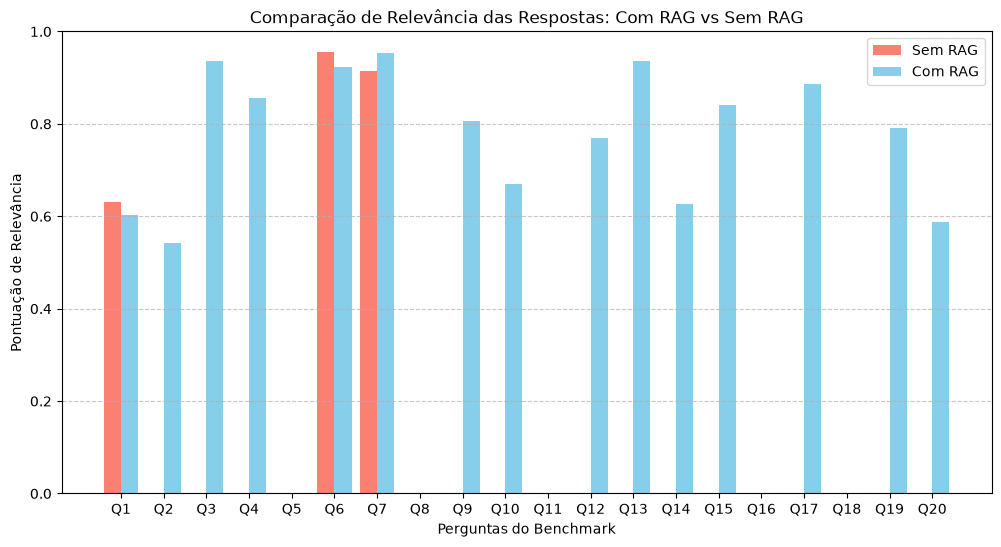

In [ ]:
relevancia_sem_rag = resultado_sem_rag.to_pandas()["answer_relevancy"].tolist()
relevancia_com_rag = resultado_com_rag.to_pandas()["answer_relevancy"].tolist()

labels = [f"Q{i+1}" for i in range(len(relevancia_sem_rag))]
x = range(len(labels))
plt.figure(figsize=(12, 6))
plt.bar(x, relevancia_sem_rag, width=0.4, label="Sem RAG", color="salmon")
plt.bar([i + 0.4 for i in x], relevancia_com_rag, width=0.4, label="Com RAG", color="skyblue")
plt.xlabel("Perguntas do Benchmark")
plt.ylabel("Pontuação de Relevância")
plt.title("Comparação de Relevância das Respostas: Com RAG vs Sem RAG")
plt.xticks([i + 0.2 for i in x], labels)
plt.legend()
plt.ylim(0, 1) 
plt.grid(axis="y", linestyle="--", alpha=0.7)

In [ ]:
import pandas as pd
tabela_comparativa = pd.DataFrame({
    "Pergunta": resultado_sem_rag.to_pandas()["user_input"],
    "Resposta Sem RAG": resultado_sem_rag.to_pandas()["response"],
    "Resposta Com RAG": resultado_com_rag.to_pandas()["response"],
    "Resposta Esperada": [item["ground_truth"] for item in benchmark_base]
})
display(tabela_comparativa)

,Pergunta,Resposta Sem RAG,Resposta Com RAG,Resposta Esperada
0,Qual centro oferece suporte aos alunos do Município de Aroazes?,"Geralmente, o suporte aos alunos em nível municipal é oferecido pela **Secretaria Municipal de Educação (SME)** do município correspondente e por meio das escolas públicas locais que atuam como centros de apoio pedagógico ou educacional. No caso específico do Município de Aroazes, se houver uma estrutura dedicada específica, ela costuma ser gerenciada diretamente pelos órgãos municipais de educação localizados na sede da cidade.\n\nNo entanto, é importante notar que informações detalhadas sobre infraestruturas específicas (como nomes exatos de ""centros"" ou unidades) podem variar dependendo do tamanho e organização administrativa daquele município específico. Para obter a informação mais precisa e atualizada sobre o centro de suporte aos alunos em Aroazes, recomenda-se consultar diretamente:\n\n1. **A Secretaria Municipal de Educação** da cidade;\n2. As escolas públicas principais localizadas no Município de Aroazes; ou\n3. O site oficial do município (se disponível), onde geralmente há informações sobre a rede educacional e serviços oferecidos.","De acordo com a **Lei nº 364/2025**, o centro que oferece suporte especializado aos alunos da Rede Municipal de Ensino é o **Centro Integrado Multidisciplinar (CIM)**.\n\n**Artigo 1º:** Fica a Prefeitura Municipal de Aroazes autorizada a implantar o Centro Integrado Multidisciplinar - CIM, para atendimento especializado às crianças, adolescentes e adultos.",O Centro Integrado Multidisciplinar - CIM.
1,"Em qual localidade e horário ocorreu a solenidade conjunta de posse dos Vereadores, Prefeito e Vice-prefeita de Aroazes em 01/01/2025?","Como modelo de inteligência artificial com base em conhecimento prévio, não tenho acesso a informações específicas sobre eventos locais recentes ou futuros que ainda não foram amplamente divulgados nos meus dados de treinamento. A solenidade conjunta de posse para o mandato 2025-2028 (ou período correspondente) na cidade de **Aroazes**, Bahia, em data específica como **01/01/2025** ainda não está disponível no meu banco de conhecimento geral atualizado.\n\nGeralmente, essas solenidades ocorrem em locais públicos emblemáticos da administração municipal, como a frente do Palácio Municipal ou na Praça da Cidade, mas o horário exato e localidade específica dependem das decisões tomadas pela Prefeitura naquele momento específico para 2025.\n\nPara obter informações precisas sobre o local e o horário dessa cerimônia:\n1. Verifique os canais oficiais de comunicação da **Prefeitura Municipal de Aroazes**.\n2. Consulte portais de notícias locais ou regionais que cobrem a região do norte da Bahia, uma vez que esses detalhes são frequentemente divulgados com antecedência imediata antes da data do evento.","A solenidade conjunta de posse ocorreu, em 01/01/2025 (primeiro dia do mês de janeiro), às 19h, no Ginásio de Esportes da Unidade Escolar Municipal Manoel Portela de Carvalho, sede do Poder Legislativo na cidade de Aroazes.\n\nConforme o art. 4°, parágrafo único do Regimento Interno da Câmara Municipal, os trabalhos foram presididos pelo vereador mais idoso dentre os eleitos.","No Ginásio de Esportes da unidade Escolar Manoel Portela de Carvalho, às 19:00h."
2,Qual é o número de telefone da Prefeitura de Aroazes listado em suas publicações?,,"De acordo com o contexto fornecido, o número de telefone listado nas publicações do Município de Aroazes é **(89) 3468-1264**. Este contato aparece nos documentos da Câmara Municipal de Aroazes - PI (Portaria e Decreto), que compartilham a mesma estrutura administrativa e endereço com os atos da Prefeitura.",(89) 3468-1345
3,Qual é o endereço completo da Prefeitura Municipal de Elesbão Veloso informado nos documentos de 2025?,,"O endereço completo da Prefeitura Municipal de Elesbão Veloso, conforme informado nos documentos publicados no Diário Oficial em dezembro de 2025, é:\n\n**Praça José Mar

In [102]:
tabela_comparativa.to_excel("comparacao_rag_sem_rag.xlsx", index=False)
print("Tabela comparativa salva como 'comparacao_rag_sem_rag.xlsx'")

Tabela comparativa salva como 'comparacao_rag_sem_rag.xlsx'
